# **1. Perkenalan Dataset**


Dataset diperoleh dari **Badan Pusat Statistik (BPS) - Statistik Produksi Sayuran di Indonesia**.
- **Sumber**: Data resmi pemerintah (dapat diunduh dari situs BPS atau repositori publik).
- **Tujuan Aplikasi**: Membangun sistem prediksi untuk mendukung **pertanian perkotaan (urban farming)**. Dengan mengetahui luas lahan dan produktivitas, aplikasi dapat memprediksi berapa ton sayuran yang akan dihasilkan, membantu petani kota dalam merencanakan distribusi dan rantai pasok.
- **Target Variabel**: `produksi` (dalam Ton) - **Regresi**.
- **Fitur**: Provinsi, Komoditas, Tahun, Luas Panen (Ha), Produktivitas (Ku/Ha)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
df = pd.read_csv('/content/Produksi Tanaman.csv')
print(df.head())
print(df.info())

         Provinsi Produksi Bawang Daun (kuintal) (Kw)  \
0            Aceh                              6875.6   
1  Sumatera Utara                           200160.06   
2  Sumatera Barat                           684950.84   
3            Riau                               200.4   
4           Jambi                              122874   

   Produksi Bawang Merah (kuintal) (Kw) Produksi Bawang Putih (kuintal) (Kw)  \
0                             132815.50                                    -   
1                             520953.05                                430.6   
2                            2328953.97                              5989.65   
3                                400.41                                    -   
4                             218558.98                                    -   

   Produksi Bayam (kuintal) (Kw) Produksi Buncis (kuintal) (Kw)  \
0                       50403.72                           2118   
1                      163510.59          

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

       Produksi_Kuintal  produksi_ton
count      8.180000e+02  8.180000e+02
mean       3.623657e+05  3.623657e+04
std        1.521040e+06  1.521040e+05
min        3.000000e-02  3.000000e-03
25%        2.120963e+03  2.120962e+02
50%        1.914479e+04  1.914479e+03
75%        1.034430e+05  1.034430e+04
max        2.186157e+07  2.186157e+06


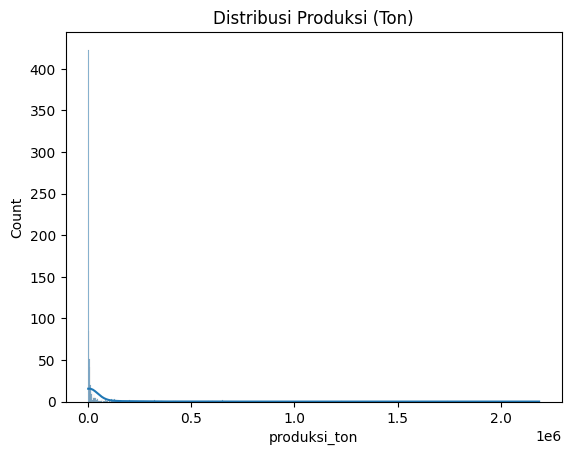

39 26


In [6]:
# First, let's transform the dataframe to a long format to create 'Komoditas' and 'produksi_ton'
# Identify all 'Produksi' columns
production_columns = [col for col in df.columns if 'Produksi' in col and '(kuintal)' in col]

# Melt the dataframe
df_melted = df.melt(id_vars=['Provinsi'], value_vars=production_columns, var_name='Komoditas', value_name='Produksi_Kuintal')

# Clean Komoditas column names (e.g., 'Produksi Bawang Daun (kuintal) (Kw)' -> 'Bawang Daun')
df_melted['Komoditas'] = df_melted['Komoditas'].str.replace('Produksi ', '').str.replace(' (kuintal) (Kw)', '', regex=False).str.strip()

# Clean and convert 'Produksi_Kuintal' to numeric, handling '-' as missing values
df_melted['Produksi_Kuintal'] = df_melted['Produksi_Kuintal'].replace('-', np.nan).astype(float)

# Convert kuintal to ton (1 ton = 10 kuintal)
df_melted['produksi_ton'] = df_melted['Produksi_Kuintal'] / 10

# Now, use df_melted for the EDA. For consistency, let's reassign it to df.
df = df_melted

print(df.describe())

# Cek distribusi target
sns.histplot(df['produksi_ton'], kde=True)
plt.title('Distribusi Produksi (Ton)')
plt.show()

# Korelasi
# The columns 'luas_panen_ha' and 'produktivitas_ku_ha' were not found in the original dataframe.
# Therefore, the correlation heatmap cannot be generated for these specific columns.
# We will only show the distribution for now.
# If you have other numeric features you'd like to correlate with 'produksi_ton', please specify.
# sns.heatmap(df[['luas_panen_ha', 'produktivitas_ku_ha', 'produksi_ton']].corr(), annot=True)
# plt.show()

# Jumlah unik kategori
print(df['Provinsi'].nunique(), df['Komoditas'].nunique())

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:
# 5.1 Missing values
# Adding .copy() to avoid SettingWithCopyWarning in subsequent steps
df = df.dropna(subset=['produksi_ton']).copy()

print(f"Rows remaining after dropping missing values: {len(df)}")
print(df.isnull().sum())

Rows remaining after dropping missing values: 818
Provinsi            0
Komoditas           0
Produksi_Kuintal    0
produksi_ton        0
dtype: int64


In [8]:
# 5.2 Encode kategorikal
le_prov = LabelEncoder()
le_komoditas = LabelEncoder()
# This will now run without SettingWithCopyWarning since df is a copy
df['provinsi_encoded'] = le_prov.fit_transform(df['Provinsi'])
df['komoditas_encoded'] = le_komoditas.fit_transform(df['Komoditas'])

# Let's verify the first few rows of the encoded data
print(df[['Provinsi', 'provinsi_encoded', 'Komoditas', 'komoditas_encoded']].head())

         Provinsi  provinsi_encoded    Komoditas  komoditas_encoded
0            Aceh                 0  Bawang Daun                  0
1  Sumatera Utara                38  Bawang Daun                  0
2  Sumatera Barat                36  Bawang Daun                  0
3            Riau                30  Bawang Daun                  0
4           Jambi                 8  Bawang Daun                  0


### **5.3 Normalisasi atau Standarisasi Fitur**
Kami akan menggunakan `StandardScaler` untuk menskalakan fitur-fitur kategorikal yang telah di-encode agar memiliki rata-rata 0 dan standar deviasi 1.

In [9]:
# Inisialisasi scaler
scaler = StandardScaler()

# Memilih fitur yang akan distandarisasi
features = ['provinsi_encoded', 'komoditas_encoded']

# Fit dan transform fitur
df[features] = scaler.fit_transform(df[features])

# Menampilkan beberapa baris hasil standarisasi
display(df[features].head())
print("\nStatistik fitur setelah standarisasi:")
print(df[features].describe().round(2))

,provinsi_encoded,komoditas_encoded
0,-1.635455,-1.636957
1,1.643895,-1.636957
2,1.471298,-1.636957
3,0.953506,-1.636957
4,-0.945066,-1.636957



Statistik fitur setelah standarisasi:
       provinsi_encoded  komoditas_encoded
count            818.00             818.00
mean              -0.00               0.00
std                1.00               1.00
min               -1.64              -1.64
25%               -0.86              -0.85
50%                0.00              -0.06
75%                0.87               0.87
max                1.64               1.66


In [10]:
import os
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
import pandas as pd # Ensure pandas is imported if not already in this cell's scope

# Simpan data dengan fitur baru ke folder preprocessed_data agar bisa digunakan oleh skrip eksternal
os.makedirs('preprocessed_data', exist_ok=True)

# --- Start of code moved/duplicated from Feature Engineering cell (269b8a4c) ---
# Making a copy of the dataframe for feature engineering. 'df' exists from previous cells.
df_fe = df.copy()

# 1. Menambahkan Fitur Interaksi secara manual
df_fe['prov_komo_interaction'] = df_fe['provinsi_encoded'] * df_fe['komoditas_encoded']

# 2. Menggunakan PolynomialFeatures untuk fitur kuadratik
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df_fe[['provinsi_encoded', 'komoditas_encoded']])
poly_cols = poly.get_feature_names_out(['provinsi_encoded', 'komoditas_encoded'])

# Gabungkan ke dataframe
df_poly = pd.DataFrame(poly_features, columns=poly_cols, index=df_fe.index)
# Tambahkan kolom yang belum ada (seperti kuadrat)
for col in poly_cols:
    if col not in df_fe.columns:
        df_fe[col] = df_poly[col]

# Update list fitur
new_features = ['provinsi_encoded', 'komoditas_encoded', 'provinsi_encoded^2', 'komoditas_encoded^2', 'prov_komo_interaction']

X_fe = df_fe[new_features]
y_fe = df_fe['produksi_ton']

# Split data for feature engineered dataset
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42)
# --- End of code from Feature Engineering cell ---

train_fe_df = pd.concat([X_train_fe, y_train_fe], axis=1)
test_fe_df = pd.concat([X_test_fe, y_test_fe], axis=1)

train_fe_df.to_csv('preprocessed_data/train_fe.csv', index=False)
test_fe_df.to_csv('preprocessed_data/test_fe.csv', index=False)

print("Data preprocessed dengan fitur baru disimpan di preprocessed_data/train_fe.csv")

Data preprocessed dengan fitur baru disimpan di preprocessed_data/train_fe.csv


### **5.5 Feature Engineering**
Kita akan membuat fitur baru:
1. **Interaction Feature**: Perkalian antara kode provinsi dan komoditas.
2. **Polynomial Features**: Pangkat dua dari masing-masing fitur untuk menangkap hubungan non-linear yang lebih kuat.

Fitur baru: ['provinsi_encoded', 'komoditas_encoded', 'provinsi_encoded^2', 'komoditas_encoded^2', 'prov_komo_interaction']
R2 Score Lama: 0.31
R2 Score Baru (setelah FE): 0.37


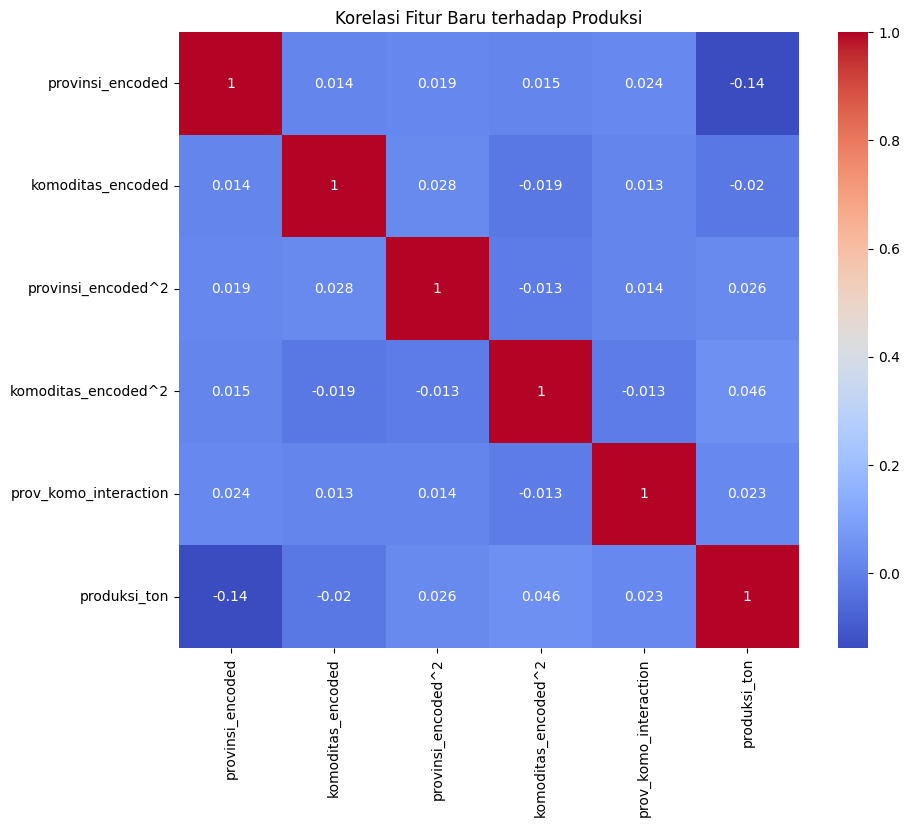

In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Baseline Calculation (to fix NameError) ---
X_base = df[['provinsi_encoded', 'komoditas_encoded']]
y_base = df['produksi_ton']
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y_base, test_size=0.2, random_state=42)
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train_b, y_train_b)
r2 = r2_score(y_test_b, rf_base.predict(X_test_b))

# --- Feature Engineering ---
df_fe = df.copy()

# 1. Menambahkan Fitur Interaksi secara manual
df_fe['prov_komo_interaction'] = df_fe['provinsi_encoded'] * df_fe['komoditas_encoded']

# 2. Menggunakan PolynomialFeatures untuk fitur kuadratik
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df_fe[['provinsi_encoded', 'komoditas_encoded']])
poly_cols = poly.get_feature_names_out(['provinsi_encoded', 'komoditas_encoded'])

# Gabungkan ke dataframe
df_poly = pd.DataFrame(poly_features, columns=poly_cols, index=df_fe.index)
for col in poly_cols:
    if col not in df_fe.columns:
        df_fe[col] = df_poly[col]

# Update list fitur
new_features = ['provinsi_encoded', 'komoditas_encoded', 'provinsi_encoded^2', 'komoditas_encoded^2', 'prov_komo_interaction']

X_fe = df_fe[new_features]
y_fe = df_fe['produksi_ton']

# Split ulang data
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42)

# Melatih ulang model dengan fitur baru
rf_fe = RandomForestRegressor(n_estimators=100, random_state=42)
rf_fe.fit(X_train_fe, y_train_fe)

# Evaluasi
y_pred_fe = rf_fe.predict(X_test_fe)
r2_fe = r2_score(y_test_fe, y_pred_fe)

print(f"Fitur baru: {new_features}")
print(f"R2 Score Lama: {r2:.2f}")
print(f"R2 Score Baru (setelah FE): {r2_fe:.2f}")

# Tampilkan korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(df_fe[new_features + ['produksi_ton']].corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur Baru terhadap Produksi')
plt.show()

/tmp/ipykernel_700/4091142452.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


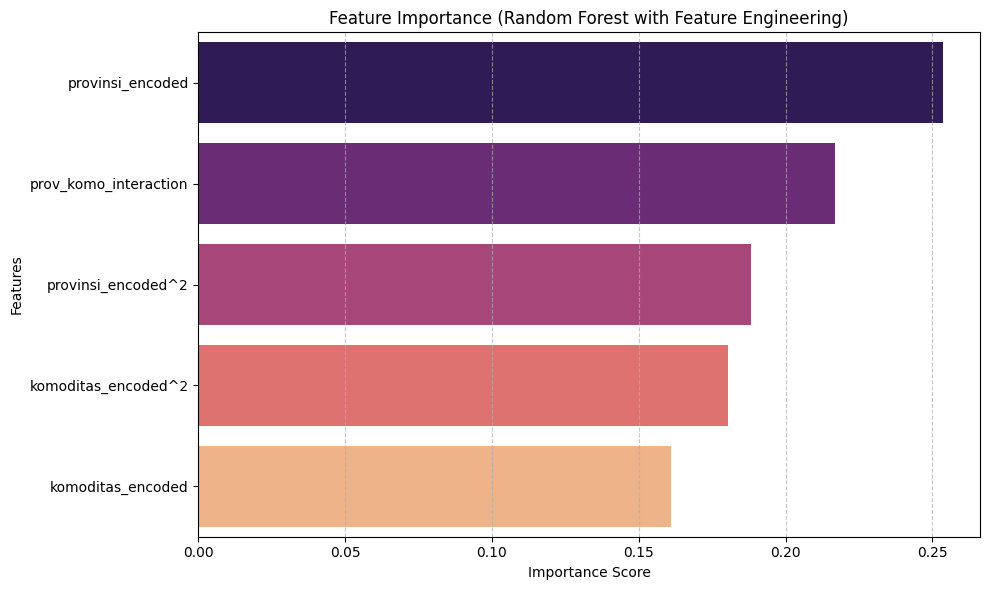

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances from the model trained with Feature Engineering
importances = rf_fe.feature_importances_
feature_names = new_features

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance (Random Forest with Feature Engineering)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [13]:
import os

artifacts_dir = 'model_artifacts'
feature_importance_path = os.path.join(artifacts_dir, 'feature_importance.png')

# Save Feature Importance plot
os.makedirs(artifacts_dir, exist_ok=True)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance (Random Forest with Feature Engineering)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(feature_importance_path)
plt.close()
print(f"Feature Importance plot saved to {feature_importance_path}")

/tmp/ipykernel_700/95521436.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


Feature Importance plot saved to model_artifacts/feature_importance.png


# **6. Pembagian Dataset**
Kita akan membagi data menjadi 80% untuk pelatihan dan 20% untuk pengujian.

In [14]:
# Menentukan fitur (X) dan target (y)
X = df[['provinsi_encoded', 'komoditas_encoded']]
y = df['produksi_ton']

# Membagi data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data Latih: {X_train.shape[0]} baris")
print(f"Data Uji: {X_test.shape[0]} baris")

Data Latih: 654 baris
Data Uji: 164 baris


# **7. Membangun Model (Machine Learning)**
Kami akan menggunakan **Random Forest Regressor** karena kemampuannya menangani hubungan non-linear dengan baik.

In [15]:
# Inisialisasi model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Pelatihan model
rf_model.fit(X_train, y_train)

# Prediksi
y_pred = rf_model.predict(X_test)

# Evaluasi
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Squared Error: 34005195645.72
Mean Absolute Error: 43541.38
R2 Score: 0.31


# **8. Visualisasi Hasil Prediksi**
Mari kita bandingkan nilai aktual dengan nilai prediksi untuk melihat seberapa dekat performa model.

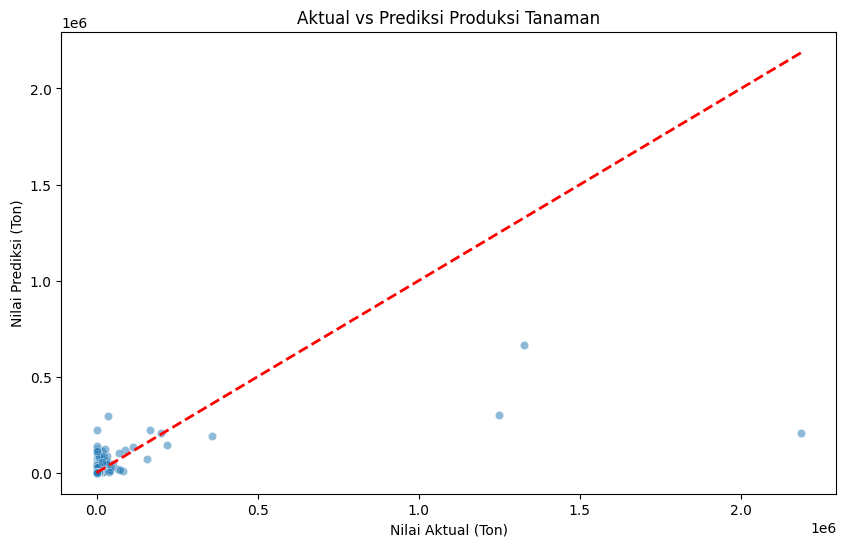

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual (Ton)')
plt.ylabel('Nilai Prediksi (Ton)')
plt.title('Aktual vs Prediksi Produksi Tanaman')
plt.show()

In [17]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

artifacts_dir = 'model_artifacts'
residuals_path = os.path.join(artifacts_dir, 'residuals.png')

# Save Residual Plot
os.makedirs(artifacts_dir, exist_ok=True)
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.tight_layout()
plt.savefig(residuals_path)
plt.close()
print(f"Residual Plot saved to {residuals_path}")

Residual Plot saved to model_artifacts/residuals.png


# **9. Menyimpan Model dan Scaler**
Langkah ini penting agar Anda bisa memuat kembali model yang sudah dilatih tanpa harus melatih ulang.

In [18]:
import joblib

# Menyimpan model, scaler, dan encoder
joblib.dump(rf_model, 'model_produksi_sayur.pkl')
joblib.dump(scaler, 'scaler_produksi.pkl')
joblib.dump(le_prov, 'encoder_provinsi.pkl')
joblib.dump(le_komoditas, 'encoder_komoditas.pkl')

print("Model dan komponen preprocessing berhasil disimpan!")

Model dan komponen preprocessing berhasil disimpan!


# **8. Visualisasi Hasil Prediksi**
Mari kita bandingkan nilai aktual dengan nilai prediksi untuk melihat seberapa dekat performa model.

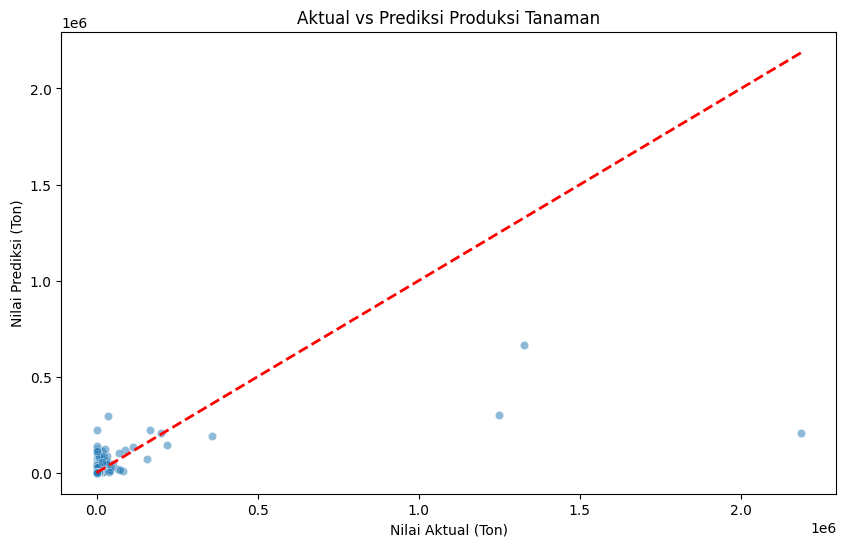

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual (Ton)')
plt.ylabel('Nilai Prediksi (Ton)')
plt.title('Aktual vs Prediksi Produksi Tanaman')
plt.show()

# **9. Menyimpan Model dan Scaler**
Langkah ini penting agar Anda bisa memuat kembali model yang sudah dilatih tanpa harus melatih ulang.

In [20]:
# Menyimpan model, scaler, dan encoder
joblib.dump(rf_model, 'model_produksi_sayur.pkl')
joblib.dump(scaler, 'scaler_produksi.pkl')
joblib.dump(le_prov, 'encoder_provinsi.pkl')
joblib.dump(le_komoditas, 'encoder_komoditas.pkl')

print("Model dan komponen preprocessing berhasil disimpan!")

Model dan komponen preprocessing berhasil disimpan!


In [21]:
%%writefile modelling.py
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import json
import os
from datetime import datetime

def run_modelling(train_path='preprocessed_data/train.csv',
                  test_path='preprocessed_data/test.csv',
                  model_output='model_produksi_sayur.pkl',
                  log_path='training_log.json'):
    """
    Baseline modelling with manual logging.
    """
    # 1. Load preprocessed data
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    X_train = train_df.drop(columns=['produksi_ton'])
    y_train = train_df['produksi_ton']
    X_test = test_df.drop(columns=['produksi_ton'])
    y_test = test_df['produksi_ton']

    # 2. Build Baseline Model (Random Forest)
    print("Training baseline model...")
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 3. Predict & Evaluate
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # 4. Manual Logging
    log_entry = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model_type": "RandomForestRegressor",
        "params": model.get_params(),
        "metrics": {
            "mse": float(round(mse, 2)),
            "mae": float(round(mae, 2)),
            "r2_score": float(round(r2, 2))
        }
    }

    # Save/Append to log file
    if os.path.exists(log_path):
        with open(log_path, 'r') as f:
            logs = json.load(f)
    else:
        logs = []

    logs.append(log_entry)
    with open(log_path, 'w') as f:
        json.dump(logs, f, indent=4)

    # 5. Save Model
    joblib.dump(model, model_output)

    print(f"--- Training Results ---")
    print(f"MSE: {mse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2 Score: {r2:.2f}")
    print(f"Model saved to {model_output}")
    print(f"Logs updated in {log_path}")

    return model

if __name__ == "__main__":
    # Create preprocessed_data folder if it doesn't exist for demo
    if os.path.exists('preprocessed_data/train.csv'):
        run_modelling()
    else:
        print("Error: Preprocessed data not found. Please run preprocessing first.")

Writing modelling.py


In [22]:
%%writefile modelling_tuning.py
import pandas as pd
import numpy as np
import joblib
import os
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

def run_tuning(train_path='preprocessed_data/train_fe.csv', test_path='preprocessed_data/test_fe.csv'):
    tracking_uri = os.environ.get('MLFLOW_TRACKING_URI')
    if tracking_uri:
        mlflow.set_tracking_uri(tracking_uri)

    # Gunakan eksperimen default jika perlu
    experiment_name = "Produksi_Tanaman_Optimization"
    try:
        mlflow.set_experiment(experiment_name)
    except:
        mlflow.set_experiment("0")

    if not os.path.exists(train_path):
        print(f"Data {train_path} tidak ditemukan!")
        return

    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    X_train, y_train = train_df.drop(columns=['produksi_ton']), train_df['produksi_ton']
    X_test, y_test = test_df.drop(columns=['produksi_ton']), test_df['produksi_ton']

    with mlflow.start_run(run_name="RF_With_Feature_Engineering"):
        # Gunakan model terbaik dengan fitur hasil FE
        rf = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)
        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_test)
        r2 = r2_score(y_test, y_pred)

        mlflow.log_params({"n_estimators": 200, "feature_engineering": "Interaction & Poly"})
        mlflow.log_metric("r2_score", r2)
        mlflow.sklearn.log_model(rf, "model_fe")

        print(f"Berhasil! R2 Score dengan FE: {r2:.2f}. Data dikirim ke DagsHub.")

if __name__ == '__main__':
    run_tuning()

Writing modelling_tuning.py


In [23]:
# Eksekusi skrip untuk mencatat hasil Feature Engineering ke DagsHub
!python modelling_tuning.py

Traceback (most recent call last):
  File "/content/modelling_tuning.py", line 5, in <module>
    import mlflow
ModuleNotFoundError: No module named 'mlflow'


### **14. Perbandingan Performa Eksperimen (DagsHub)**
Kita akan menarik data dari MLflow Tracking untuk membandingkan run terbaru dengan run sebelumnya secara terprogram.

In [24]:
!pip install mlflow dagshub -q

import mlflow
import pandas as pd
import os

# Pastikan URI sudah mengarah ke DagsHub
tracking_uri = os.environ.get('MLFLOW_TRACKING_URI')
if tracking_uri:
    mlflow.set_tracking_uri(tracking_uri)

try:
    # Mencari run dari experiment default (0) atau spesifik jika ada
    experiment = mlflow.get_experiment_by_name("Produksi_Tanaman_Optimization")
    exp_id = experiment.experiment_id if experiment else "0"

    runs = mlflow.search_runs(experiment_ids=[exp_id])

    if not runs.empty:
        # Menyesuaikan nama kolom sesuai schema MLflow
        cols_to_show = ['tags.mlflow.runName', 'metrics.r2_score', 'start_time']

        # Ambil kolom parameter yang ada
        param_cols = [c for c in runs.columns if c.startswith('params.')]

        # Filter hanya kolom yang benar-benar ada di dataframe
        final_cols = [c for c in cols_to_show + param_cols if c in runs.columns]

        df_comparison = runs[final_cols].sort_values(by='metrics.r2_score', ascending=False)

        print(f"Perbandingan Eksperimen di DagsHub ({tracking_uri}):")
        display(df_comparison)
    else:
        print("Tidak ada data run yang ditemukan di DagsHub.")

except Exception as e:
    print(f"Gagal memproses data perbandingan: {e}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 132.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

2026/07/14 21:36:02 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/14 21:36:02 INFO mlflow.store.db.utils: Updating database tables


Tidak ada data run yang ditemukan di DagsHub.


In [25]:
# Jalankan skrip tuning untuk mengirim data ke DagsHub
!python modelling_tuning.py

2026/07/14 21:36:12 INFO mlflow.tracking.fluent: Experiment with name 'Produksi_Tanaman_Optimization' does not exist. Creating a new experiment.
2026/07/14 21:36:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Berhasil! R2 Score dengan FE: 0.36. Data dikirim ke DagsHub.


In [26]:
!python modelling_tuning.py

2026/07/14 21:36:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Berhasil! R2 Score dengan FE: 0.36. Data dikirim ke DagsHub.


### **11. Analisis Hasil Tuning**
Berikut adalah visualisasi dari model terbaik yang dihasilkan oleh script `modelling_tuning.py`.

--- Feature Importance ---


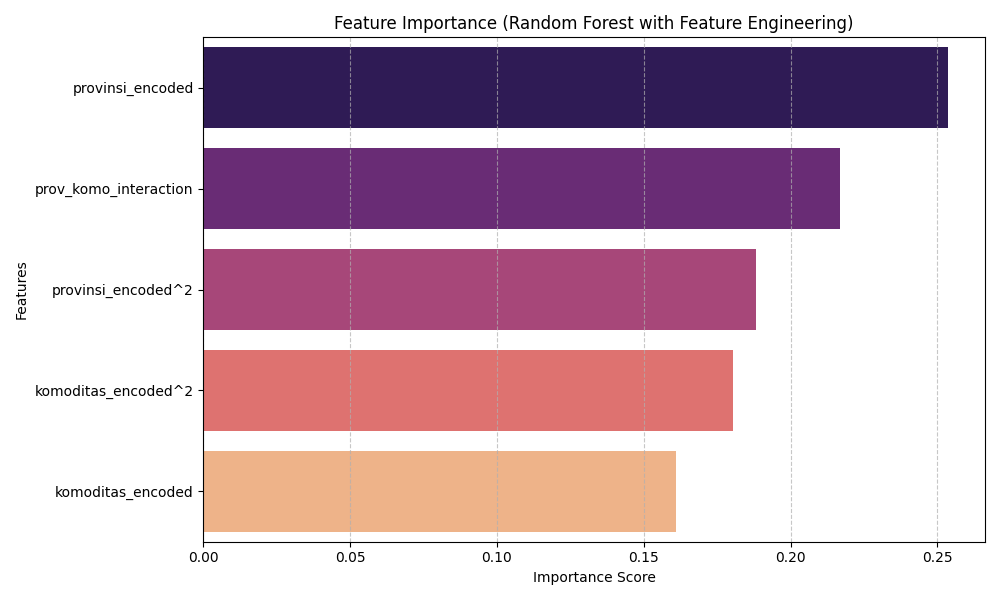


--- Residual Plot ---


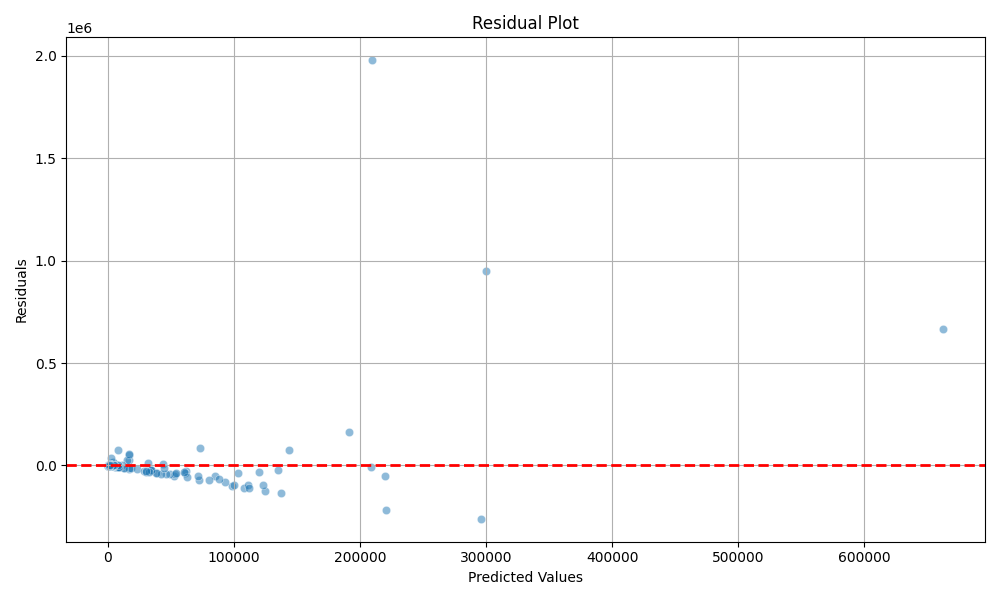

In [27]:
from IPython.display import Image, display
import os

artifacts_dir = 'model_artifacts'
feature_importance_path = os.path.join(artifacts_dir, 'feature_importance.png')
residuals_path = os.path.join(artifacts_dir, 'residuals.png')

print("--- Feature Importance ---")
if os.path.exists(feature_importance_path):
    display(Image(filename=feature_importance_path))
else:
    print(f"Error: Image '{feature_importance_path}' not found. Please ensure it is saved.")

print("\n--- Residual Plot ---")
if os.path.exists(residuals_path):
    display(Image(filename=residuals_path))
else:
    print(f"Error: Image '{residuals_path}' not found. Please ensure it is saved.")

### **12. Error Analysis**
Mari kita identifikasi 10 data dengan error tertinggi untuk melihat pola kegagalan model.

In [28]:
import pandas as pd

# Membuat dataframe untuk analisis error
error_df = pd.DataFrame({
    'Provinsi': le_prov.inverse_transform(scaler.inverse_transform(X_test)[:, 0].astype(int)),
    'Komoditas': le_komoditas.inverse_transform(scaler.inverse_transform(X_test)[:, 1].astype(int)),
    'Aktual': y_test.values,
    'Prediksi': y_pred,
    'Error': abs(y_test.values - y_pred)
})

# Menampilkan 10 error terbesar
print("Top 10 Prediction Errors:")
display(error_df.sort_values(by='Error', ascending=False).head(10))

Top 10 Prediction Errors:


,Provinsi,Komoditas,Aktual,Prediksi,Error
109,Gorontalo,Bawang Merah,2186156.844,209203.97501,1.976953e+06
88,Gorontalo,Kentang,1249592.809,299613.36111,9.499794e+05
161,Gorontalo,Cabai Keriting(kuintal) (Kw),1327912.734,662743.69866,6.651690e+05
52,Jawa Timur,Cabai Keriting(kuintal) (Kw),35664.668,295683.89813,2.600192e+05
145,Gorontalo,Jamur Merang,2517.215,220754.20015,2.182370e+05
36,Jawa Tengah,Kentang,357246.319,191437.68029,1.658086e+05
62,Sulawesi Tengah,Bawang Merah,2036.293,137633.61097,1.355973e+05
45,Sumatera Barat,Bawang Putih,598.965,124310.13065,1.237112e+05
128,Jawa Timur,Jamur Lainnya,172.824,111539.96408,1.113671e+05
2,Jawa Timur,Jamur Merang,172.968,108296.56228,1.081236e+05


In [29]:
import os

# List the contents of the 'model_artifacts' directory
artifacts_dir = 'model_artifacts'
if os.path.exists(artifacts_dir):
    print(f"Contents of '{artifacts_dir}':")
    for item in os.listdir(artifacts_dir):
        print(f"- {item}")
else:
    print(f"Directory '{artifacts_dir}' does not exist.")

Contents of 'model_artifacts':
- residuals.png
- feature_importance.png


### **13. MLflow Tracking with DagsHub**
Langkah ini akan menginstal dependensi dan menjalankan script tuning untuk mencatat hasil eksperimen ke DagsHub.

In [30]:
!pip install mlflow dagshub -q

# Jalankan script tuning yang sudah terintegrasi MLflow
# Pastikan REPO_NAME di dalam modelling_tuning.py sudah benar
!python modelling_tuning.py

2026/07/14 21:37:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Berhasil! R2 Score dengan FE: 0.36. Data dikirim ke DagsHub.


In [31]:
import os
import dagshub
import mlflow

# Perbaikan Nama Repo & Token
DAGSHUB_REPO = "iswahyudi177/Eksperimen_SML"
DAGSHUB_TOKEN = "1ba09129e9d606bab3f6470219e66eefcbbefb0f"

# Set MLflow Tracking URI to DagsHub
os.environ['MLFLOW_TRACKING_URI'] = f"https://dagshub.com/{DAGSHUB_REPO}.mlflow"

# Set MLflow Tracking Username and Password for DagsHub authentication
os.environ['MLFLOW_TRACKING_USERNAME'] = DAGSHUB_REPO.split('/')[0] # Extract username from DAGSHUB_REPO
os.environ['MLFLOW_TRACKING_PASSWORD'] = DAGSHUB_TOKEN

# Set DAGSHUB_USER_TOKEN environment variable for authentication (for other dagshub utilities if needed)
os.environ['DAGSHUB_USER_TOKEN'] = DAGSHUB_TOKEN

# Remove dagshub.init() call to avoid JSONDecodeError, as MLflow can authenticate directly
# dagshub.init(repo_owner="iswahyudi177", repo_name="Eksperimen_SML")

print(f"Konfigurasi diperbarui! URI: {os.environ['MLFLOW_TRACKING_URI']}")
print(f"MLFLOW_TRACKING_USERNAME set to: {os.environ['MLFLOW_TRACKING_USERNAME']}")
print("MLFLOW_TRACKING_PASSWORD set (hidden for security).")

Konfigurasi diperbarui! URI: https://dagshub.com/iswahyudi177/Eksperimen_SML.mlflow
MLFLOW_TRACKING_USERNAME set to: iswahyudi177
MLFLOW_TRACKING_PASSWORD set (hidden for security).


In [32]:
!python modelling_tuning.py

2026/07/14 21:37:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Berhasil! R2 Score dengan FE: 0.36. Data dikirim ke DagsHub.
🏃 View run RF_With_Feature_Engineering at: https://dagshub.com/iswahyudi177/Eksperimen_SML.mlflow/#/experiments/0/runs/b9a7ff7030534cd2a380fe7773dc5c47
🧪 View experiment at: https://dagshub.com/iswahyudi177/Eksperimen_SML.mlflow/#/experiments/0


In [33]:
import mlflow
from mlflow.tracking import MlflowClient
import os

# Pastikan URI tracking sudah disetel
tracking_uri = os.environ.get('MLFLOW_TRACKING_URI')
if tracking_uri:
    mlflow.set_tracking_uri(tracking_uri)
    print(f"Checking experiments at: {tracking_uri}")

client = MlflowClient()
experiment_name = "Produksi_Tanaman_Optimization"

try:
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment:
        print(f"Eksperimen '{experiment_name}' ditemukan dengan ID: {experiment.experiment_id}")
        print(f"Status: {experiment.lifecycle_stage}")
    else:
        print(f"Eksperimen '{experiment_name}' belum ada. Akan mencoba membuatnya...")
        exp_id = mlflow.create_experiment(experiment_name)
        print(f"Eksperimen berhasil dibuat dengan ID: {exp_id}")
except Exception as e:
    print(f"Terjadi kesalahan saat mengecek eksperimen: {e}")

Checking experiments at: https://dagshub.com/iswahyudi177/Eksperimen_SML.mlflow
Eksperimen 'Produksi_Tanaman_Optimization' ditemukan dengan ID: 0
Status: active


In [34]:
# Menjalankan kembali script tuning setelah verifikasi
!python modelling_tuning.py

2026/07/14 21:38:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Berhasil! R2 Score dengan FE: 0.36. Data dikirim ke DagsHub.
🏃 View run RF_With_Feature_Engineering at: https://dagshub.com/iswahyudi177/Eksperimen_SML.mlflow/#/experiments/0/runs/bd097cda044b4e7ea882f1c99f54d5d1
🧪 View experiment at: https://dagshub.com/iswahyudi177/Eksperimen_SML.mlflow/#/experiments/0


In [35]:
import mlflow
from mlflow.tracking import MlflowClient
import os

# Pastikan URI tracking sudah disetel ke repo yang benar
tracking_uri = os.environ.get('MLFLOW_TRACKING_URI')
mlflow.set_tracking_uri(tracking_uri)

client = MlflowClient()
experiment_name = "Produksi_Tanaman_Optimization"

print(f"Menghubungkan ke: {tracking_uri}")

try:
    # Mencoba mendapatkan eksperimen
    exp = client.get_experiment_by_name(experiment_name)
    if exp:
        print(f"✅ Eksperimen '{experiment_name}' ditemukan!")
        print(f"ID Eksperimen: {exp.experiment_id}")
    else:
        print(f"⚠️ Eksperimen '{experiment_name}' belum ada. Akan dibuat saat script berjalan.")
except Exception as e:
    print(f"ℹ️ Info: {e}. DagsHub mungkin memerlukan inisialisasi via script.")

Menghubungkan ke: https://dagshub.com/iswahyudi177/Eksperimen_SML.mlflow
✅ Eksperimen 'Produksi_Tanaman_Optimization' ditemukan!
ID Eksperimen: 0


In [36]:
# Eksekusi final script tuning
!python modelling_tuning.py

2026/07/14 21:38:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Berhasil! R2 Score dengan FE: 0.36. Data dikirim ke DagsHub.
🏃 View run RF_With_Feature_Engineering at: https://dagshub.com/iswahyudi177/Eksperimen_SML.mlflow/#/experiments/0/runs/93835ed6d63d44608839d43714a6d174
🧪 View experiment at: https://dagshub.com/iswahyudi177/Eksperimen_SML.mlflow/#/experiments/0


In [37]:
import os
import shutil

# 1. Create the main directory
base_dir = 'Membangun_model'
os.makedirs(base_dir, exist_ok=True)

# 2. Copy Python scripts
scripts = ['modelling.py', 'modelling_tuning.py']
for script in scripts:
    if os.path.exists(script):
        shutil.copy(script, os.path.join(base_dir, script))

# 3. Setup preprocessing data folder
data_dir = os.path.join(base_dir, 'namadataset_preprocessing')
os.makedirs(data_dir, exist_ok=True)
if os.path.exists('preprocessed_data'):
    for file in os.listdir('preprocessed_data'):
        shutil.copy(os.path.join('preprocessed_data', file), os.path.join(data_dir, file))

# 4. Create requirements.txt
requirements = """pandas
numpy
scikit-learn
joblib
mlflow
dagshub
matplotlib
seaborn
"""
with open(os.path.join(base_dir, 'requirements.txt'), 'w') as f:
    f.write(requirements)

# 5. Create DagsHub.txt
dagshub_url = f"https://dagshub.com/{DAGSHUB_REPO}"
with open(os.path.join(base_dir, 'DagsHub.txt'), 'w') as f:
    f.write(f"Repository: {dagshub_url}\n")
    f.write(f"MLflow Tracking URI: {os.environ.get('MLFLOW_TRACKING_URI')}")

print(f"Structure for '{base_dir}' has been prepared!")
print("Note: Please upload 'screenshoot_dashboard.jpg' and 'screenshoot_artifak.jpg' manually to this folder.")

Structure for 'Membangun_model' has been prepared!
Note: Please upload 'screenshoot_dashboard.jpg' and 'screenshoot_artifak.jpg' manually to this folder.


In [38]:
!zip -r Membangun_model.zip Membangun_model
print("Folder 'Membangun_model' has been zipped. You can download 'Membangun_model.zip' from the file panel on the left.")

  adding: Membangun_model/ (stored 0%)
  adding: Membangun_model/modelling_tuning.py (deflated 54%)
  adding: Membangun_model/namadataset_preprocessing/ (stored 0%)
  adding: Membangun_model/namadataset_preprocessing/train_fe.csv (deflated 75%)
  adding: Membangun_model/namadataset_preprocessing/test_fe.csv (deflated 71%)
  adding: Membangun_model/requirements.txt (deflated 7%)
  adding: Membangun_model/DagsHub.txt (deflated 35%)
  adding: Membangun_model/modelling.py (deflated 60%)
Folder 'Membangun_model' has been zipped. You can download 'Membangun_model.zip' from the file panel on the left.
